核心思想是：如果一个特征几乎不变化，它能提供的区分信息通常很少，因此可以优先考虑去掉。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

In [5]:
iris = load_iris()
X = iris.data
y = iris.target

iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['species'] = pd.Categorical.from_codes(y, iris.target_names)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


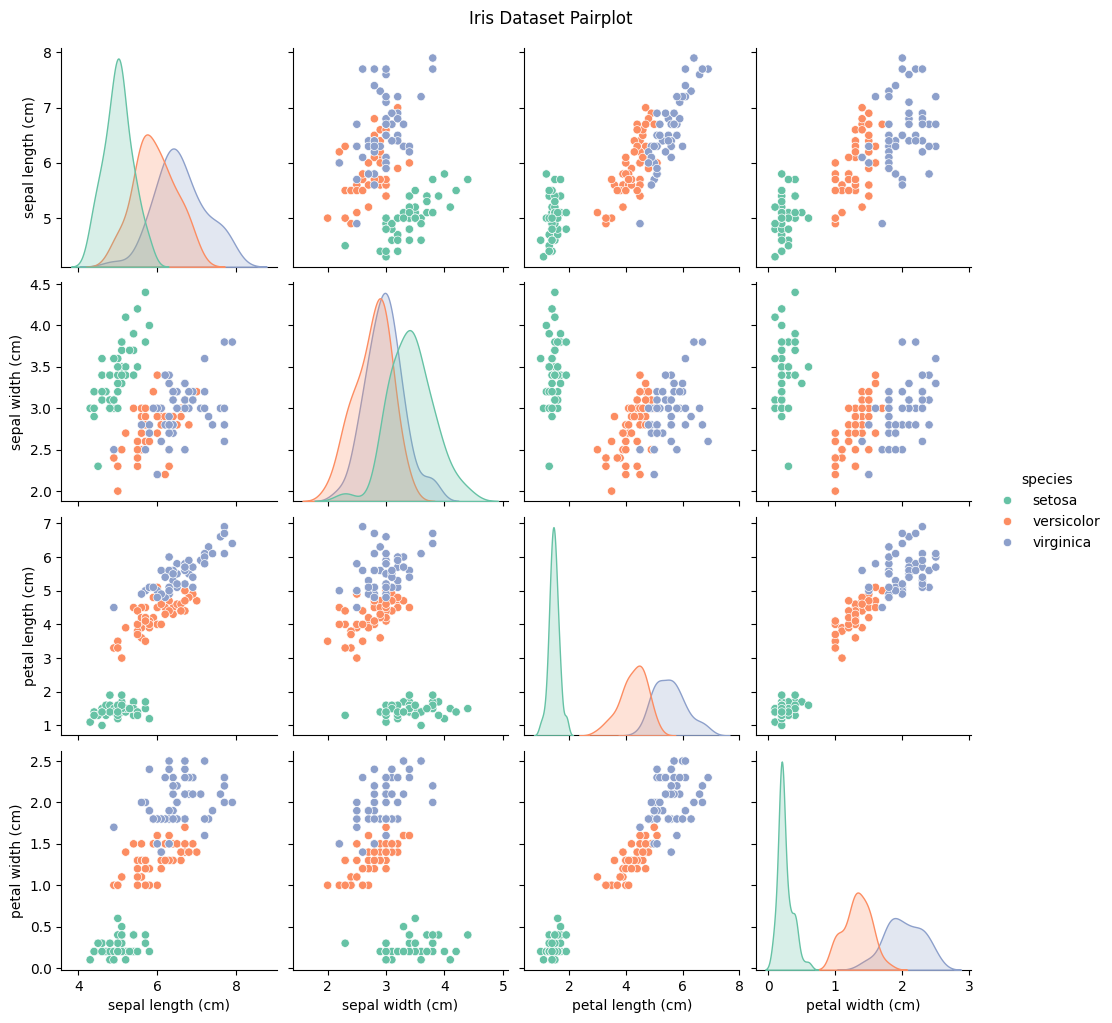

In [7]:
sns.pairplot(iris_df, hue="species", palette="Set2")
plt.suptitle("Iris Dataset Pairplot", y=1.02)
plt.show()

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled, columns=iris.feature_names).head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


In [11]:
selector = VarianceThreshold(threshold=0.5)  # 设定方差阈值为0.5
X_selected = selector.fit_transform(X_scaled)
selected_features = np.array(iris.feature_names)[selector.get_support()]
print("Selected Features:", selected_features)

Selected Features: ['sepal length (cm)' 'sepal width (cm)' 'petal length (cm)'
 'petal width (cm)']


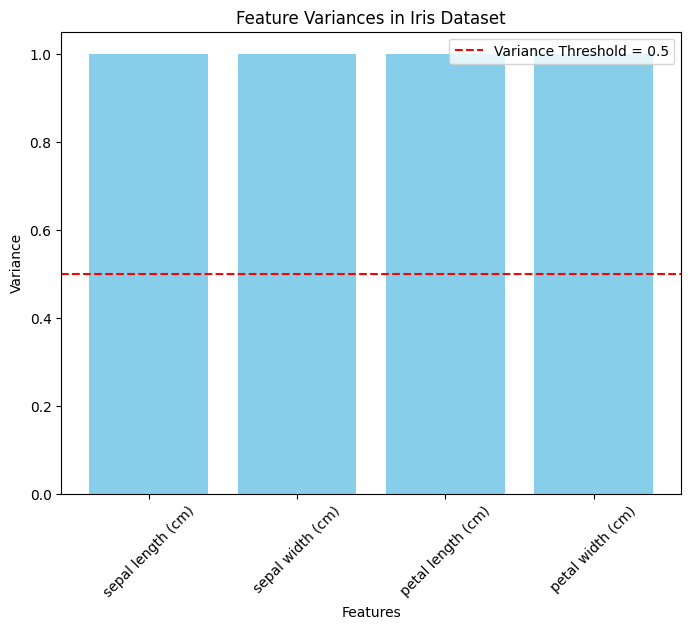

In [12]:
variances = np.var(X_scaled, axis=0)

plt.figure(figsize=(8, 6))
plt.bar(iris.feature_names, variances, color='skyblue')
plt.axhline(y=0.5, color='red', linestyle='--', label="Variance Threshold = 0.5")
plt.title("Feature Variances in Iris Dataset")
plt.ylabel("Variance")
plt.xlabel("Features")
plt.legend()
plt.xticks(rotation=45)
plt.show()

Accuracy with selected features: 1.0


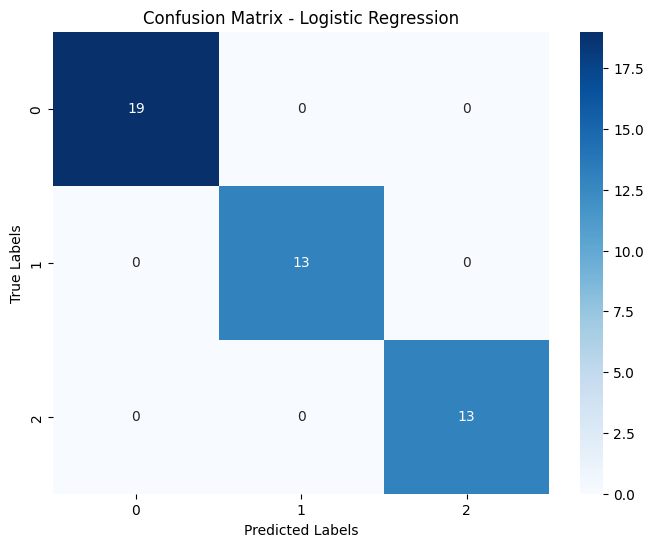

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

model = LogisticRegression(max_iter=200)
model.fit(X_train[:, selector.get_support()], y_train)

y_pred = model.predict(X_test[:, selector.get_support()])
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy with selected features:", accuracy)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

thresholds = np.linspace(0, 1, 20)

best_threshold = 0
best_score = 0
for threshold in thresholds:
    selector = VarianceThreshold(threshold=threshold)
    X_selected = selector.fit_transform(X_scaled)

    if X_selected.shape[1] == 0:
        continue  # Skip if no features are selected

    model = LogisticRegression(max_iter=200)
    scores = cross_val_score(model, X_selected, y, cv=5)
    mean_score = np.mean(scores)

    if mean_score > best_score:
        best_score = mean_score
        best_threshold = threshold

In [15]:
print(f"Best Variance Threshold: {best_threshold}")
print(f"Best Cross-Validation Score: {best_score:.4f}")

Best Variance Threshold: 0.0
Best Cross-Validation Score: 0.9600
